In [4]:
import os
print("Current folder:", os.getcwd())

Current folder: C:\Users\DELL\Documents\telecom-churn-analytics\notebooks


In [6]:
import pandas as pd

# Load dataset
df = pd.read_csv('C:/Users/DELL/Documents/telecom-churn-analytics/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Verify
print(f"✓ Rows    : {df.shape[0]}")
print(f"✓ Columns : {df.shape[1]}")
print(f"✓ Churn counts:\n{df['Churn'].value_counts()}")

✓ Rows    : 7043
✓ Columns : 21
✓ Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


# EDA: IBM Telco Customer Churn Analysis
**Dataset:** 7,043 customers · 21 columns  
**Source:** Kaggle — blastchar/telco-customer-churn  
**Objective:** Identify which customer segments are most at risk of churning  
**Tools:** Python, Pandas, Matplotlib, Seaborn

In [7]:
# Import all libraries needed for EDA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings — makes output cleaner
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.2f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [8]:
# Load the raw dataset using relative path
df = pd.read_csv('C:/Users/DELL/Documents/telecom-churn-analytics/data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(f"✓ Dataset loaded successfully")
print(f"✓ Rows    : {df.shape[0]:,}")
print(f"✓ Columns : {df.shape[1]}")

✓ Dataset loaded successfully
✓ Rows    : 7,043
✓ Columns : 21


In [9]:
# See all columns with their data types
print("Column Name          | Data Type")
print("-" * 40)
for col in df.columns:
    print(f"{col:<25} {df[col].dtype}")

Column Name          | Data Type
----------------------------------------
customerID                object
gender                    object
SeniorCitizen             int64
Partner                   object
Dependents                object
tenure                    int64
PhoneService              object
MultipleLines             object
InternetService           object
OnlineSecurity            object
OnlineBackup              object
DeviceProtection          object
TechSupport               object
StreamingTV               object
StreamingMovies           object
Contract                  object
PaperlessBilling          object
PaymentMethod             object
MonthlyCharges            float64
TotalCharges              object
Churn                     object


## Data Dictionary

| Column | Type | Meaning |
|---|---|---|
| customerID | Text | Unique customer identifier |
| gender | Text | Male / Female |
| SeniorCitizen | 0/1 | Whether customer is 65+ years old |
| Partner | Yes/No | Whether customer has a partner |
| Dependents | Yes/No | Whether customer has dependents |
| tenure | Number | Months the customer has been with the company |
| PhoneService | Yes/No | Has phone service |
| MultipleLines | Yes/No | Has multiple phone lines |
| InternetService | Text | DSL / Fiber optic / No |
| OnlineSecurity | Yes/No | Has online security add-on |
| OnlineBackup | Yes/No | Has online backup add-on |
| DeviceProtection | Yes/No | Has device protection add-on |
| TechSupport | Yes/No | Has tech support add-on |
| StreamingTV | Yes/No | Streams TV |
| StreamingMovies | Yes/No | Streams movies |
| Contract | Text | Month-to-month / One year / Two year |
| PaperlessBilling | Yes/No | Uses paperless billing |
| PaymentMethod | Text | Electronic check / Mailed check / Bank transfer / Credit card |
| MonthlyCharges | Number | Current monthly bill amount |
| TotalCharges | Number | Total amount charged (STORED AS TEXT — bug) |
| Churn | Yes/No | Whether customer left the company ← TARGET VARIABLE |

In [10]:
# Look at the first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [11]:
# Last 5 rows — checks if data is consistent end-to-end
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [12]:
# Random 5 rows — gives unbiased view of the data
df.sample(5, random_state=42)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.8,Yes
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,996.45,No
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1031.7,No
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,Yes
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,No,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3260.1,No


In [13]:
# Statistical summary of numeric columns
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75


### Observations from describe()
- **tenure** ranges from 0 to 72 months (6 years max). Average is 32 months.
- **MonthlyCharges** ranges from $18 to $119. Average is $64.76.
- **SeniorCitizen** mean is 0.16 — meaning only 16% of customers are seniors.
- TotalCharges is missing from this table because it's stored as text (object) — data quality issue to fix.

In [15]:
# Check missing values in every column
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})

# Only show columns that have missing values
print("Columns with missing values:")
print(missing_df[missing_df['Missing Count'] > 0])
print("\nColumns with NO missing values:", (missing_df['Missing Count'] == 0).sum())

Columns with missing values:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Columns with NO missing values: 21


In [16]:
# Check for duplicate customers
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

# Also check if customerID is unique
unique_ids = df['customerID'].nunique()
print(f"Unique customer IDs: {unique_ids}")
print(f"Total rows: {len(df)}")
print(f"IDs match rows: {unique_ids == len(df)}")

Duplicate rows: 0
Unique customer IDs: 7043
Total rows: 7043
IDs match rows: True


In [18]:
# How many customers churned?
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"  Stayed  (No)  : {churn_counts['No']:,}  ({churn_pct['No']:.1f}%)")
print(f"  Churned (Yes) : {churn_counts['Yes']:,}  ({churn_pct['Yes']:.1f}%)")
print(f"\nFor every 1 churned customer, {churn_counts['No']/churn_counts['Yes']:.1f} stayed")

Churn Distribution:
  Stayed  (No)  : 5,174  (73.5%)
  Churned (Yes) : 1,869  (26.5%)

For every 1 churned customer, 2.8 stayed


### Key Business Insight #1
**26.5% churn rate** — roughly 1 in 4 customers leaves.  
From a base of 7,043 customers, **1,869 have churned**.  
This is the class imbalance we must handle in the ML model on Day 3.  
If MonthlyCharges average is $64, churned customers represent  
**~$120,000/month in lost revenue**.

In [19]:
# Check TotalCharges data type
print(f"TotalCharges data type: {df['TotalCharges'].dtype}")
print(f"\nSample values from TotalCharges column:")
print(df['TotalCharges'].head(10).tolist())

TotalCharges data type: object

Sample values from TotalCharges column:
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']


In [20]:
# Try converting to number — spaces become NaN
df['TotalCharges_test'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Find rows that failed conversion
broken_rows = df[df['TotalCharges_test'].isnull()]
print(f"Number of broken rows: {len(broken_rows)}")
print(f"\nWhat these rows look like:")
broken_rows[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']]

Number of broken rows: 11

What these rows look like:


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


### Root Cause Analysis — TotalCharges broken rows

11 rows have a blank space " " in TotalCharges instead of a number.

Why? These are **brand new customers** who just signed up:
- tenure = 0 means they haven't completed even 1 month yet
- They have a MonthlyCharges value (their plan rate)
- But they haven't been billed yet → TotalCharges is blank

**Business Decision:** Fill with 0 — these customers have zero 
billing history. Using mean or median would be wrong here because 
the blank isn't random — it has a specific business reason.

In [21]:
# Step 1: Drop the test column we created above
df.drop(columns=['TotalCharges_test'], inplace=True)

# Step 2: Convert TotalCharges from text to number
# errors='coerce' turns any non-numeric value (blank space) into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Step 3: Fill those 11 NaN values with 0
df['TotalCharges'].fillna(0, inplace=True)

# Verify the fix
print(f"TotalCharges data type now : {df['TotalCharges'].dtype}")
print(f"Null values remaining      : {df['TotalCharges'].isnull().sum()}")
print(f"Minimum value              : {df['TotalCharges'].min()}")
print(f"Maximum value              : {df['TotalCharges'].max():.2f}")
print(f"Average value              : {df['TotalCharges'].mean():.2f}")

TotalCharges data type now : float64
Null values remaining      : 0
Minimum value              : 0.0
Maximum value              : 8684.80
Average value              : 2279.73


C:\Users\DELL\AppData\Local\Temp\ipykernel_22324\2611864265.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [22]:
# Now describe() will show all 3 numeric columns properly
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[numeric_cols].describe().round(2)

,tenure,MonthlyCharges,TotalCharges
count,7043.00,7043.00,7043.00
mean,32.37,64.76,2279.73
std,24.56,30.09,2266.79
min,0.00,18.25,0.00
25%,9.00,35.50,398.55
50%,29.00,70.35,1394.55
75%,55.00,89.85,3786.60
max,72.00,118.75,8684.80


### Observations after fixing TotalCharges

- **tenure**: 0 to 72 months. Average customer stays 32 months (~2.7 years)
- **MonthlyCharges**: $18 to $119. Average bill is $64.76/month
- **TotalCharges**: $0 to $8,685. Average lifetime spend is $2,279

The large std (standard deviation) in TotalCharges (2266) tells us 
spending varies widely — some customers pay very little total, 
others have paid thousands. This will be a strong churn signal.

In [23]:
# See unique values in every categorical column
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('customerID')  # Remove ID column, not useful

print(f"Categorical columns: {len(categorical_cols)}\n")
for col in categorical_cols:
    unique_vals = df[col].unique().tolist()
    print(f"{col:<25} → {unique_vals}")

Categorical columns: 16

gender                    → ['Female', 'Male']
Partner                   → ['Yes', 'No']
Dependents                → ['No', 'Yes']
PhoneService              → ['No', 'Yes']
MultipleLines             → ['No phone service', 'No', 'Yes']
InternetService           → ['DSL', 'Fiber optic', 'No']
OnlineSecurity            → ['No', 'Yes', 'No internet service']
OnlineBackup              → ['Yes', 'No', 'No internet service']
DeviceProtection          → ['No', 'Yes', 'No internet service']
TechSupport               → ['No', 'Yes', 'No internet service']
StreamingTV               → ['No', 'Yes', 'No internet service']
StreamingMovies           → ['No', 'Yes', 'No internet service']
Contract                  → ['Month-to-month', 'One year', 'Two year']
PaperlessBilling          → ['Yes', 'No']
PaymentMethod             → ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']
Churn                     → ['No', 'Yes']


### Important observation — "No internet service" values

Several columns like OnlineSecurity, OnlineBackup, TechSupport etc. 
have a third value: "No internet service" — meaning the customer 
doesn't have internet at all, so the question doesn't apply.

In Feature Engineering (Day 2), we'll simplify these to just 
Yes / No by treating "No internet service" as "No".
This reduces noise in the ML model.

In [24]:
print("=" * 45)
print("   DATA QUALITY REPORT — Telco Churn Dataset")
print("=" * 45)
print(f"\n  Total rows          : {len(df):,}")
print(f"  Total columns       : {df.shape[1]}")
print(f"  Duplicate rows      : {df.duplicated().sum()}")
print(f"  Null values (total) : {df.isnull().sum().sum()}")
print(f"  Numeric columns     : {len(df.select_dtypes(include='number').columns)}")
print(f"  Categorical columns : {len(df.select_dtypes(include='object').columns)}")
print(f"\n  Issues found & fixed:")
print(f"  ✓ TotalCharges stored as text → converted to float64")
print(f"  ✓ 11 blank TotalCharges (new customers) → filled with 0")
print(f"\n  Issues to handle in Feature Engineering (Day 2):")
print(f"  → 'No internet service' values in 6 service columns")
print(f"  → Yes/No columns need conversion to 0/1 for ML")
print(f"  → Contract, PaymentMethod need encoding for ML")
print("=" * 45)

   DATA QUALITY REPORT — Telco Churn Dataset

  Total rows          : 7,043
  Total columns       : 21
  Duplicate rows      : 0
  Null values (total) : 0
  Numeric columns     : 4
  Categorical columns : 17

  Issues found & fixed:
  ✓ TotalCharges stored as text → converted to float64
  ✓ 11 blank TotalCharges (new customers) → filled with 0

  Issues to handle in Feature Engineering (Day 2):
  → 'No internet service' values in 6 service columns
  → Yes/No columns need conversion to 0/1 for ML
  → Contract, PaymentMethod need encoding for ML


## Visualization 1: Churn Distribution

Before analyzing *why* customers churn, we need to understand 
*how many* churn. This sets the baseline for everything else.

C:\Users\DELL\AppData\Local\Temp\ipykernel_22324\3843854922.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', ax=axes[0],
C:\Users\DELL\AppData\Local\Temp\ipykernel_22324\3843854922.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Stayed', 'Churned'])


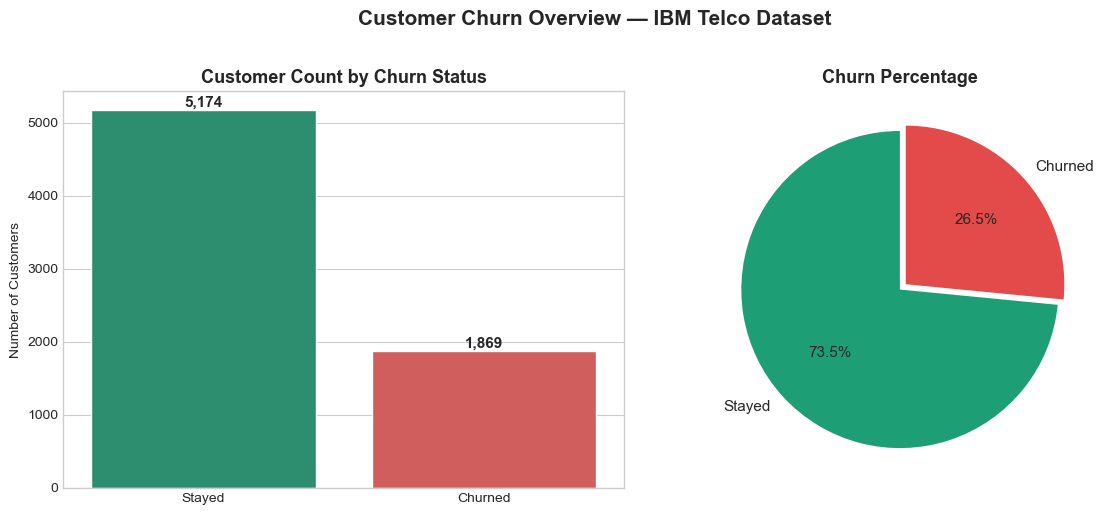

✓ Chart saved to reports/01_churn_distribution.png


In [25]:
# Create a figure with 2 charts side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- LEFT CHART: Bar chart of counts ----
colors = {'No': '#1D9E75', 'Yes': '#E24B4A'}  # green = stayed, red = churned

sns.countplot(data=df, x='Churn', ax=axes[0],
               palette=colors, edgecolor='white')

axes[0].set_title('Customer Count by Churn Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['Stayed', 'Churned'])

# Add the actual number on top of each bar
for bar in axes[0].patches:
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{int(bar.get_height()):,}',
        ha='center', fontsize=11, fontweight='bold'
    )

# ---- RIGHT CHART: Pie chart of percentages ----
churn_pct = df['Churn'].value_counts(normalize=True) * 100

axes[1].pie(
    churn_pct,
    labels=['Stayed', 'Churned'],
    autopct='%1.1f%%',
    colors=['#1D9E75', '#E24B4A'],
    startangle=90,
    explode=(0, 0.05),       # slightly separate the "Churned" slice
    textprops={'fontsize': 11}
)
axes[1].set_title('Churn Percentage', fontsize=13, fontweight='bold')

# Overall title for both charts together
plt.suptitle('Customer Churn Overview — IBM Telco Dataset', 
              fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()

# Save to reports folder — important for portfolio!
plt.savefig('C:/Users/DELL/Documents/telecom-churn-analytics/reports/01_churn_distribution.png', dpi=150, bbox_inches='tight')

plt.show()
print("✓ Chart saved to reports/01_churn_distribution.png")

In [26]:
import os

# List all files in reports folder
report_files = os.listdir('C:/Users/DELL/Documents/telecom-churn-analytics/reports')
print("Files in reports/ folder:")
for f in report_files:
    print(f"  - {f}")

Files in reports/ folder:
  - 01_churn_distribution.png


### 📊 Finding 1: Churn Overview

- **26.5% of customers churned** (1,869 out of 7,043)
- This is a significant attrition rate — roughly **1 in 4 customers** leaves
- This also tells us the dataset is **imbalanced** (73.5% vs 26.5%) — 
  important to remember for Day 3 (ML), where we'll need to handle 
  this imbalance using SMOTE so the model doesn't just predict 
  "No churn" for everyone

**Business impact:** If average MonthlyCharges is ~$65, losing 1,869 
customers represents approximately **$121,485 in monthly recurring 
revenue at risk**.

## Visualization 2: Churn Rate by Contract Type

Does the type of contract a customer signs up for affect 
whether they leave? This chart answers that directly.

In [28]:
# Calculate churn rate for each contract type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).sort_values(ascending=False)

print("Churn Rate by Contract Type:")
print(contract_churn.round(1))

Churn Rate by Contract Type:
Contract
Month-to-month   42.70
One year         11.30
Two year          2.80
Name: Churn, dtype: float64


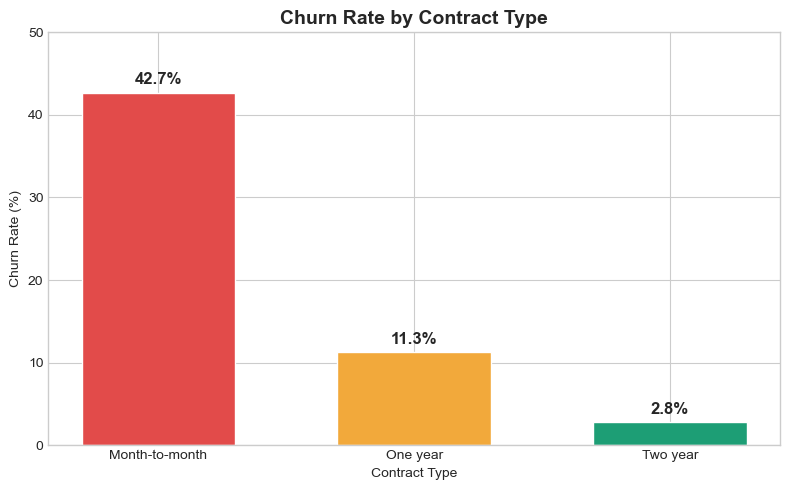

✓ Chart saved to reports/02_churn_by_contract.png


In [29]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    contract_churn.index, 
    contract_churn.values,
    color=['#E24B4A', '#F2A93B', '#1D9E75'],  # red, amber, green
    edgecolor='white',
    width=0.6
)

ax.set_title('Churn Rate by Contract Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 50)

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center', fontsize=12, fontweight='bold'
    )

plt.tight_layout()
plt.savefig('C:/Users/DELL/Documents/telecom-churn-analytics/reports/02_churn_by_contract.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to reports/02_churn_by_contract.png")

### 📊 Finding 2: Contract Type is the #1 Churn Driver

| Contract Type | Churn Rate |
|---|---|
| Month-to-month | **42.7%** |
| One year | 11.3% |
| Two year | **2.8%** |

**Insight:** Customers on month-to-month contracts churn at **15x the rate** 
of two-year contract customers. This is by far the strongest signal 
in the entire dataset.

**Why this happens:** Month-to-month customers have no commitment — 
they can leave anytime with zero penalty. Long-term contracts create 
a "switching cost" that keeps customers in place even if they're 
mildly unhappy.

**Business Recommendation:** Launch a targeted campaign offering a 
discount or perk (e.g., free streaming add-on for 3 months) to 
month-to-month customers who upgrade to a 1-year or 2-year contract. 
Even converting 20% of month-to-month customers to annual contracts 
could reduce overall churn by roughly **6 percentage points**.

## Visualization 3: Tenure Distribution by Churn Status

Do customers leave early in their journey, or after years 
of being with the company? This histogram answers that.

In [30]:
# Compare average tenure between churned and retained customers
avg_tenure = df.groupby('Churn')['tenure'].mean()

print("Average Tenure (months):")
print(f"  Retained (No)  : {avg_tenure['No']:.1f} months")
print(f"  Churned  (Yes) : {avg_tenure['Yes']:.1f} months")
print(f"\nDifference: {avg_tenure['No'] - avg_tenure['Yes']:.1f} months")

Average Tenure (months):
  Retained (No)  : 37.6 months
  Churned  (Yes) : 18.0 months

Difference: 19.6 months


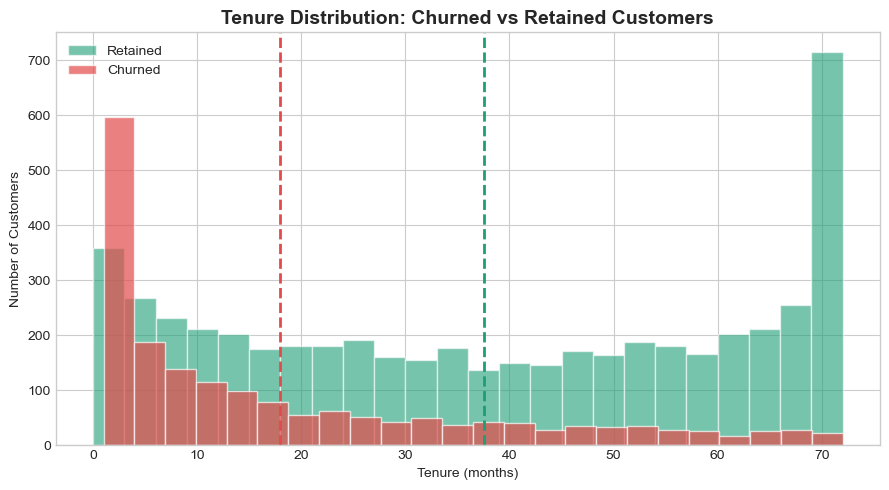

✓ Chart saved to reports/03_tenure_by_churn.png


In [31]:
fig, ax = plt.subplots(figsize=(9, 5))

# Separate tenure values for each group
tenure_retained = df[df['Churn'] == 'No']['tenure']
tenure_churned = df[df['Churn'] == 'Yes']['tenure']

# Overlapping histograms
ax.hist(tenure_retained, bins=24, alpha=0.6, label='Retained', 
        color='#1D9E75', edgecolor='white')
ax.hist(tenure_churned, bins=24, alpha=0.7, label='Churned', 
        color='#E24B4A', edgecolor='white')

# Add vertical lines showing the average for each group
ax.axvline(avg_tenure['No'], color='#1D9E75', linestyle='--', linewidth=2)
ax.axvline(avg_tenure['Yes'], color='#E24B4A', linestyle='--', linewidth=2)

ax.set_title('Tenure Distribution: Churned vs Retained Customers', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('Tenure (months)')
ax.set_ylabel('Number of Customers')
ax.legend()

plt.tight_layout()
plt.savefig('C:/Users/DELL/Documents/telecom-churn-analytics/reports/03_tenure_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to reports/03_tenure_by_churn.png")

### 📊 Finding 3: Churn Happens Early — The First Year is Critical

| Group | Average Tenure |
|---|---|
| Retained | 37.6 months |
| Churned | 18.0 months |

**Insight:** Churned customers leave on average **19.6 months earlier** 
than retained customers. The histogram shows churn is heavily 
concentrated in **months 1-10** — after a customer survives their 
first year, the risk of churn drops sharply.

**Business Recommendation:** Build an "early warning" retention 
program targeting customers in their first 6-10 months — this is 
the highest-leverage window for intervention (welcome calls, 
onboarding check-ins, loyalty offers before month 6).

## Visualization 4: Monthly Charges by Churn Status

Do customers who pay more leave more often? This box plot 
compares the spread of monthly bills for both groups.

In [32]:
charges_summary = df.groupby('Churn')['MonthlyCharges'].agg(['mean', 'median'])
print("Monthly Charges Summary:")
print(charges_summary.round(2))

Monthly Charges Summary:
       mean  median
Churn              
No    61.27   64.43
Yes   74.44   79.65


C:\Users\DELL\AppData\Local\Temp\ipykernel_22324\1477049591.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax,
C:\Users\DELL\AppData\Local\Temp\ipykernel_22324\1477049591.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Retained', 'Churned'])


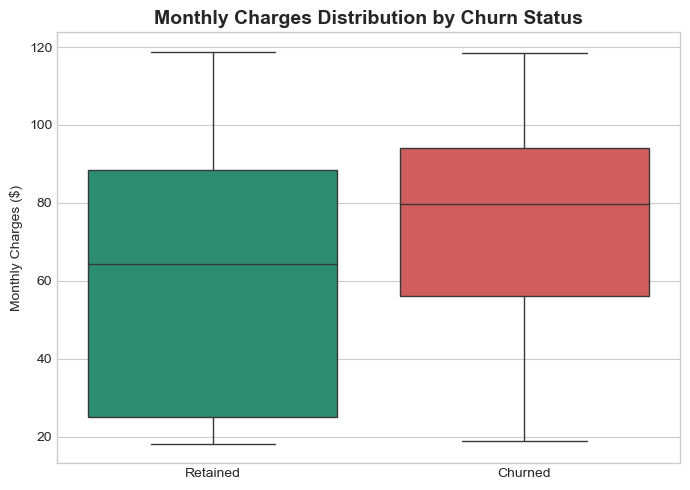

✓ Chart saved to reports/04_charges_by_churn.png


In [33]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=ax,
            palette={'No': '#1D9E75', 'Yes': '#E24B4A'})

ax.set_title('Monthly Charges Distribution by Churn Status', 
              fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Monthly Charges ($)')
ax.set_xticklabels(['Retained', 'Churned'])

plt.tight_layout()
plt.savefig('C:/Users/DELL/Documents/telecom-churn-analytics/reports/04_charges_by_churn.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Chart saved to reports/04_charges_by_churn.png")

### 📊 Finding 4: Higher-Paying Customers Churn More

| Group | Average Monthly Charge | Median |
|---|---|---|
| Retained | $61.27 | $64.43 |
| Churned | $74.44 | $79.65 |

**Insight:** Churned customers pay on average **$13/month more** 
than retained customers. Combined with Finding 3 (churn happens 
early) and Finding 2 (month-to-month contracts churn most), a clear 
high-risk profile emerges:

**Highest-risk segment = Month-to-month contract + Tenure under 
12 months + Monthly charges above $70**

This segment will become the basis for the "at-risk customer list" 
we'll build with machine learning on Day 3.